# Comparison: CHIME raw files vs processed CSVs (AQUATIME)

This notebook reads both file types and compares their content:
- **Raw CHIME** (`chime_05_belgium`, `chime_10_belgium`) — Belgian coastal station only
- **Processed CSVs** (`AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv`, `...10nm...`)

It also adds a proper `datetime` column to the convolved CSV files by matching `icase` against
the RT1 reference dataset.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg

# ── File paths ────────────────────────────────────────────────────────────────
# Raw CHIME files — Belgium station only (no meas_01)
RAW_FILES = {
    "chime_05_belgium" : cfg.DATA_RAW / "CHIME" / "chime_05_belgium",
    "chime_10_belgium" : cfg.DATA_RAW / "CHIME" / "chime_10_belgium",
}

# Processed (convolved) CSV files
CSV_FILES = {
    "5nm"  : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv",
    "10nm" : cfg.DATA_RAW / "CHIME" / "AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv",
}

# RT1 reference dataset — used to inject datetime into convolved CSVs
# Rows are ordered identically to icase (0-based index)
RT1_REF_FILE = cfg.DATA_RAW / "belgian_coast_all.csv"   # only to copy datetime info

print("✓ Configuration loaded")
print(f"  DATA_RAW : {cfg.DATA_RAW}")
print(f"  RT1 ref  : {RT1_REF_FILE}")

✓ Configuration loaded
  DATA_RAW : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\raw
  RT1 ref  : C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\raw\belgian_coast_all.csv


---
## 1. Format detection — raw CHIME files

In [2]:
def detect_and_read_raw(filepath):
    """
    Try to read a raw CHIME file by probing multiple formats.
    Returns (detected_format, loaded_object).
    """
    name = os.path.basename(filepath)

    # 1) NetCDF4 / HDF5
    try:
        import netCDF4 as nc
        ds = nc.Dataset(filepath)
        print(f"  [{name}] -> NetCDF4")
        return "netcdf", ds
    except Exception:
        pass

    # 2) Pure HDF5
    try:
        import h5py
        ds = h5py.File(filepath, "r")
        print(f"  [{name}] -> HDF5")
        return "hdf5", ds
    except Exception:
        pass

    # 3) CSV / text with delimiter
    try:
        df = pd.read_csv(filepath, sep=None, engine="python", nrows=5)
        print(f"  [{name}] -> CSV/text")
        print(f"    Detected columns : {df.columns.tolist()}")
        print(f"    First rows       :\n{df.head()}")
        print(f"    Dtypes           :\n{df.dtypes}")
        print(f"    Basic stats      :\n{df.describe(include='all')}")
        print(f"    Shape            : {df.shape}")
        df_full = pd.read_csv(filepath, sep=None, engine="python")
        print(f"    Total rows       : {len(df_full)}")
        return "csv", df_full
    except Exception:
        pass

    # 4) Raw binary numpy
    try:
        arr = np.fromfile(filepath, dtype=np.float32)
        print(f"  [{name}] -> binary float32 ({arr.shape[0]} values)")
        return "binary", arr
    except Exception:
        pass

    print(f"  [{name}] -> unknown format")
    return "unknown", None


print("Detecting format of raw files:")
raw_data = {}
for key, path in RAW_FILES.items():
    if os.path.exists(path):
        fmt, obj = detect_and_read_raw(path)
        raw_data[key] = {"fmt": fmt, "obj": obj, "path": path}
    else:
        print(f"  [{key}] -> file NOT found at {path}")

Detecting format of raw files:
  [chime_05_belgium] -> CSV/text
    Detected columns : ['icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000', '445.000000', '450.000000', '455.000000', '460.000000', '465.000000', '470.000000', '475.000000', '480.000000', '485.000000', '490.000000', '495.000000', '500.000000', '505.000000', '510.000000', '515.000000', '520.000000', '525.000000', '530.000000', '535.000000', '540.000000', '545.000000', '550.000000', '555.000000', '560.000000', '565.000000', '570.000000', '575.000000', '580.000000', '585.000000', '590.000000', '595.000000', '600.000000', '605.000000', '610.000000', '615.000000', '620.000000', '625.000000', '630.000000', '635.000000', '640.000000', '645.000000', '650.000000', '655.000000', '660.000000', '665.000000', '670.00

---
## 2. Raw file inspection — structure and metadata

In [3]:
def inspect_raw(key, info):
    fmt, obj = info["fmt"], info["obj"]
    print(f"\n{'='*60}")
    print(f" {key}  [{fmt}]")
    print(f"{'='*60}")

    if fmt == "netcdf":
        print("  Dimensions:", dict(obj.dimensions))
        print("  Variables:", list(obj.variables.keys()))
        for vname, var in obj.variables.items():
            print(f"    {vname:30s} shape={var.shape}  dtype={var.dtype}")

    elif fmt == "hdf5":
        def print_hdf5(name, obj_):
            if hasattr(obj_, "shape"):
                print(f"    {name:40s} shape={obj_.shape}  dtype={obj_.dtype}")
            else:
                print(f"    {name}/")
        obj.visititems(print_hdf5)

    elif fmt == "csv":
        print(f"  Rows: {len(obj)}   Columns: {len(obj.columns)}")
        print("  Columns:", list(obj.columns[:20]), "..." if len(obj.columns) > 20 else "")
        display(obj.head(3))

    elif fmt == "binary":
        print(f"  {obj.shape[0]} float32 values")
        print(f"  min={obj.min():.4f}  max={obj.max():.4f}  mean={obj.mean():.4f}")

for key, info in raw_data.items():
    inspect_raw(key, info)


 chime_05_belgium  [csv]
  Rows: 779   Columns: 121
  Columns: ['icase', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000', '390.000000', '395.000000', '400.000000', '405.000000', '410.000000', '415.000000', '420.000000', '425.000000', '430.000000', '435.000000', '440.000000'] ...


,icase,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,390.000000,...,900.000000,905.000000,910.000000,915.000000,920.000000,925.000000,930.000000,935.000000,940.000000,945.000000
0,0,0.042590,0.043189,0.044856,0.046275,0.047343,0.049339,0.051643,0.053817,0.056194,...,0.007098,0.006871,0.006614,0.006196,0.005677,0.005229,0.004994,0.004752,0.004441,0.004208
1,1,0.037378,0.037909,0.039379,0.040694,0.041680,0.043495,0.045572,0.047560,0.049744,...,0.006400,0.006233,0.005936,0.005604,0.005172,0.004766,0.004423,0.004307,0.003931,0.003811
2,2,0.025687,0.026093,0.027218,0.028273,0.029176,0.030719,0.032528,0.034379,0.036433,...,0.006378,0.006187,0.005995,0.005766,0.005435,0.005036,0.004816,0.004523,0.004238,0.004119



 chime_10_belgium  [csv]
  Rows: 779   Columns: 61
  Columns: ['icase', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000', '430.000000', '440.000000', '450.000000', '460.000000', '470.000000', '480.000000', '490.000000', '500.000000', '510.000000', '520.000000', '530.000000'] ...


,icase,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,430.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
0,0,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,0.072081,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,1,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,0.064654,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,2,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,0.052493,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336


---
## 3. Read processed CSVs (AQUATIME)

In [4]:
def read_aquatime_csv(filepath):
    """Read an AQUATIME CSV with automatic separator detection."""
    p = Path(filepath)
    candidates = [p]
    if p.suffix.lower() != ".csv":
        candidates.append(p.with_suffix(".csv"))
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path, sep=None, engine="python")
            return df, path
    return None, None


print("Reading processed CSVs (AQUATIME):")
csv_data = {}
for key, path in CSV_FILES.items():
    df, found_path = read_aquatime_csv(path)
    if df is not None:
        csv_data[key] = df
        print(f"  [{key}] -> {os.path.basename(found_path)}")
        print(f"           rows={len(df)}  columns={len(df.columns)}")
    else:
        print(f"  [{key}] -> file NOT found")

Reading processed CSVs (AQUATIME):
  [5nm] -> AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv
           rows=779  columns=122
  [10nm] -> AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv
           rows=779  columns=62


---
## 4. Inject datetime into convolved CSV files

The convolved CSVs have an `icase` column that indexes rows in the RT1 reference dataset
(`belgian_coast_all.csv`).  This cell:
1. Loads the RT1 reference and extracts `datetime_utc` indexed by row position.
2. Merges the datetime into each convolved CSV on `icase`.
3. Saves the updated files (overwrites in place).

In [5]:
# ── Load RT1 reference ────────────────────────────────────────────────────────
if not RT1_REF_FILE.exists():
    print(f"WARNING: RT1 reference file not found at\n  {RT1_REF_FILE}\n"
          "  Set RT1_REF_FILE in the configuration cell and rerun.")
    rt1_ref = None
else:
    rt1_ref = pd.read_csv(RT1_REF_FILE, sep=None, engine="python")

    # Detect the datetime column (accepts 'datetime_utc', 'datetime', 'date', 'time', ...)
    dt_col_candidates = [c for c in rt1_ref.columns
                         if any(k in c.lower() for k in ("datetime", "date", "time"))]
    if not dt_col_candidates:
        print("WARNING: no datetime column found in RT1 reference. "
              f"Available columns: {rt1_ref.columns.tolist()[:10]}")
        rt1_ref = None
    else:
        dt_col = dt_col_candidates[0]
        rt1_ref[dt_col] = pd.to_datetime(rt1_ref[dt_col], utc=True, errors="coerce")

        # Keep only Belgium station rows (name == 'RT1') if a 'name' column exists
        if "name" in rt1_ref.columns:
            rt1_ref = rt1_ref[rt1_ref["name"] == "RT1"].copy()
            print(f"  Filtered to RT1 (Belgium): {len(rt1_ref)} rows")

        # Build icase -> datetime lookup (row position = icase)
        rt1_ref = rt1_ref.reset_index(drop=True)
        icase_to_dt = rt1_ref[dt_col].to_dict()   # {0: Timestamp, 1: Timestamp, ...}
        print(f"  Datetime column  : '{dt_col}'")
        print(f"  icase range      : 0 – {max(icase_to_dt)}")
        print(f"  Example icase=0  : {icase_to_dt[0]}")

# ── Inject datetime into each convolved CSV ───────────────────────────────────
if rt1_ref is not None:
    for key, df in csv_data.items():
        if "icase" not in df.columns:
            print(f"  [{key}] no 'icase' column — skipping")
            continue

        # Map icase -> datetime
        df["date"] = df["icase"].map(icase_to_dt)

        # Move 'date' to be the first column after icase
        cols = ["icase", "date"] + [c for c in df.columns if c not in ("icase", "date")]
        df = df[cols]
        csv_data[key] = df

        # Check coverage
        n_matched = df["date"].notna().sum()
        print(f"  [{key}] datetime injected: {n_matched}/{len(df)} rows matched")
        print(f"           range: {df['date'].min()} -> {df['date'].max()}")

        # Save updated file
        out_path = CSV_FILES[key]
        df.to_csv(out_path, index=False)
        print(f"           saved -> {out_path.name}")

  Filtered to RT1 (Belgium): 582 rows
  Datetime column  : 'datetime_utc'
  icase range      : 0 – 581
  Example icase=0  : 2022-02-26 11:01:30+00:00
  [5nm] datetime injected: 582/779 rows matched
           range: 2020-01-06 10:41:23+00:00 -> 2024-12-28 11:03:25+00:00
           saved -> AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-5nm-v0.1.csv
  [10nm] datetime injected: 582/779 rows matched
           range: 2020-01-06 10:41:23+00:00 -> 2024-12-28 11:03:25+00:00
           saved -> AQUATIME_D2.1.0_RD-belgian-coast-chime-convolved-10nm-v0.1.csv


---
## 5. CSV inspection — columns and first rows

In [6]:
for key, df in csv_data.items():
    print(f"\n{'='*60}")
    print(f" CSV: {key}")
    print(f"{'='*60}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns ({len(df.columns)}): {list(df.columns[:10])}",
          "..." if len(df.columns) > 10 else "")
    print(f"  Dtype counts:\n{df.dtypes.value_counts().to_string()}")

    # Show temporal range if a datetime column is present
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ("date", "time"))]
    for dc in date_cols:
        df[dc] = pd.to_datetime(df[dc], errors="coerce")
        valid = df[dc].dropna()
        if not valid.empty:
            print(f"  Temporal range [{dc}]: {valid.min()} -> {valid.max()}")
        else:
            print(f"  [{dc}] all NaT / empty")

    display(df.head(3))


 CSV: 5nm
  Shape: (779, 122)
  Columns (122): ['icase', 'date', '350.000000', '355.000000', '360.000000', '365.000000', '370.000000', '375.000000', '380.000000', '385.000000'] ...
  Dtype counts:
float64                120
int64                    1
datetime64[us, UTC]      1
  Temporal range [date]: 2020-01-06 10:41:23+00:00 -> 2024-12-28 11:03:25+00:00


,icase,date,350.000000,355.000000,360.000000,365.000000,370.000000,375.000000,380.000000,385.000000,...,900.000000,905.000000,910.000000,915.000000,920.000000,925.000000,930.000000,935.000000,940.000000,945.000000
0,0,2022-02-26 11:01:30+00:00,0.042590,0.043189,0.044856,0.046275,0.047343,0.049339,0.051643,0.053817,...,0.007098,0.006871,0.006614,0.006196,0.005677,0.005229,0.004994,0.004752,0.004441,0.004208
1,1,2022-02-27 11:01:47+00:00,0.037378,0.037909,0.039379,0.040694,0.041680,0.043495,0.045572,0.047560,...,0.006400,0.006233,0.005936,0.005604,0.005172,0.004766,0.004423,0.004307,0.003931,0.003811
2,2,2022-02-28 11:41:41+00:00,0.025687,0.026093,0.027218,0.028273,0.029176,0.030719,0.032528,0.034379,...,0.006378,0.006187,0.005995,0.005766,0.005435,0.005036,0.004816,0.004523,0.004238,0.004119



 CSV: 10nm
  Shape: (779, 62)
  Columns (62): ['icase', 'date', '350.000000', '360.000000', '370.000000', '380.000000', '390.000000', '400.000000', '410.000000', '420.000000'] ...
  Dtype counts:
float64                60
int64                   1
datetime64[us, UTC]     1
  Temporal range [date]: 2020-01-06 10:41:23+00:00 -> 2024-12-28 11:03:25+00:00


,icase,date,350.000000,360.000000,370.000000,380.000000,390.000000,400.000000,410.000000,420.000000,...,850.000000,860.000000,870.000000,880.000000,890.000000,900.000000,910.000000,920.000000,930.000000,940.000000
0,0,2022-02-26 11:01:30+00:00,0.043332,0.045020,0.047565,0.051611,0.055994,0.059616,0.062693,0.066474,...,0.011252,0.010227,0.009344,0.008459,0.007708,0.007107,0.006573,0.005697,0.004994,0.004532
1,1,2022-02-27 11:01:47+00:00,0.038034,0.039541,0.041878,0.045551,0.049571,0.052972,0.055926,0.059486,...,0.010135,0.009201,0.008395,0.007638,0.006954,0.006420,0.005923,0.005179,0.004480,0.004048
2,2,2022-02-28 11:41:41+00:00,0.026188,0.027357,0.029331,0.032540,0.036328,0.039902,0.043313,0.047266,...,0.009271,0.008561,0.007976,0.007388,0.006865,0.006385,0.005984,0.005418,0.004800,0.004336


---
## 6. Extract spectral bands from raw files
> Adapt this cell if a different format is detected in Section 1

In [7]:
def extract_spectra_from_raw(key, info):
    """
    Extract wavelengths and Rrs arrays from a raw file.
    Adapt variable names to your actual format.
    """
    fmt, obj = info["fmt"], info["obj"]

    if fmt == "netcdf":
        wl_candidates  = ["wavelength", "lambda", "wl", "bands", "centre_wavelength"]
        rrs_candidates = ["Rrs", "rrs", "reflectance", "Rw", "rw", "Rho_w"]
        wl, rrs = None, None
        for c in wl_candidates:
            if c in obj.variables:
                wl = np.array(obj.variables[c][:])
                print(f"  [{key}] wavelength var -> '{c}'")
                break
        for c in rrs_candidates:
            if c in obj.variables:
                rrs = np.array(obj.variables[c][:])
                print(f"  [{key}] Rrs var        -> '{c}' shape={rrs.shape}")
                break
        return wl, rrs

    elif fmt == "hdf5":
        print(f"  [{key}] HDF5 keys: {list(obj.keys())}")
        return None, None

    elif fmt == "csv":
        # Column names that are pure floats -> wavelength bands
        wl_cols, wl_vals = [], []
        for c in obj.columns:
            try:
                v = float(c)
                wl_cols.append(c)
                wl_vals.append(v)
            except (ValueError, TypeError):
                pass
        if wl_cols:
            wl  = np.array(wl_vals)
            rrs = obj[wl_cols].values.astype(float)
            print(f"  [{key}] {len(wl)} bands ({wl[0]:.1f}-{wl[-1]:.1f} nm)  "
                  f"| {rrs.shape[0]} spectra")
            return wl, rrs
        return None, None

    elif fmt == "binary":
        print(f"  [{key}] binary — need external shape/wavelength metadata")
        return None, None

    return None, None


spectra_raw = {}
print("Extracting bands from raw files:")
for key, info in raw_data.items():
    wl, rrs = extract_spectra_from_raw(key, info)
    spectra_raw[key] = {"wl": wl, "rrs": rrs}

Extracting bands from raw files:
  [chime_05_belgium] 120 bands (350.0-945.0 nm)  | 779 spectra
  [chime_10_belgium] 60 bands (350.0-940.0 nm)  | 779 spectra


---
## 7. Extract spectral bands from CSVs
> Automatically detects numeric columns (wavelengths)

In [8]:
def extract_spectra_from_csv(key, df):
    """
    Detect columns corresponding to spectral bands.
    Assumes columns with a numeric name (or 'Rrs_NNN' pattern) are wavelengths.
    """
    print(f"  [{key}] df.shape: {df.shape}")

    # Pattern 1: pure numeric column names (e.g. '400', '405', ...)
    numeric_named = []
    for c in df.columns:
        try:
            float(c)
            numeric_named.append(c)
        except (ValueError, TypeError):
            pass

    # Pattern 2: prefixed columns like 'Rrs_400', 'wl_400', 'band_400'
    prefixed = [c for c in df.columns
                if re.match(r"(Rrs|rrs|wl|band)_?(\d+\.?\d*)", c)]

    if numeric_named:
        wl  = np.array([float(c) for c in numeric_named])
        rrs = df[numeric_named].values
        print(f"  [{key}] {len(wl)} bands ({wl[0]:.1f}-{wl[-1]:.1f} nm)  "
              f"| {rrs.shape[0]} spectra")
        return wl, rrs

    elif prefixed:
        nums = [re.search(r"(\d+\.?\d*)", c).group() for c in prefixed]
        wl  = np.array([float(n) for n in nums])
        rrs = df[prefixed].values
        print(f"  [{key}] {len(wl)} bands ({wl[0]:.1f}-{wl[-1]:.1f} nm)  "
              f"| {rrs.shape[0]} spectra")
        return wl, rrs

    else:
        print(f"  [{key}] No spectral columns detected. "
              f"Available: {list(df.columns[:10])}")
        return None, None


spectra_csv = {}
print("Extracting bands from processed CSVs:")
for key, df in csv_data.items():
    wl, rrs = extract_spectra_from_csv(key, df)
    spectra_csv[key] = {"wl": wl, "rrs": rrs}

Extracting bands from processed CSVs:
  [5nm] df.shape: (779, 122)
  [5nm] 120 bands (350.0-945.0 nm)  | 779 spectra
  [10nm] df.shape: (779, 62)
  [10nm] 60 bands (350.0-940.0 nm)  | 779 spectra


---
## 8. Spectral coverage comparison

In [9]:
print("Spectral coverage summary\n")
print(f"{'File':<30} {'Type':<8} {'N bands':>8} {'λ min':>8} {'λ max':>8} {'Δλ':>6}")
print("-" * 65)

all_spectra = ([(k, "raw", v) for k, v in spectra_raw.items()] +
               [(k, "csv", v) for k, v in spectra_csv.items()])

for name, kind, spec in all_spectra:
    wl = spec["wl"]
    if wl is not None and len(wl) > 1:
        delta = np.round(np.median(np.diff(wl)), 2)
        print(f"{name:<30} {kind:<8} {len(wl):>8} {wl[0]:>8.1f} {wl[-1]:>8.1f} {delta:>6.1f}")
    else:
        print(f"{name:<30} {kind:<8} {'—':>8}")

Spectral coverage summary

File                           Type      N bands    λ min    λ max     Δλ
-----------------------------------------------------------------
chime_05_belgium               raw           120    350.0    945.0    5.0
chime_10_belgium               raw            60    350.0    940.0   10.0
5nm                            csv           120    350.0    945.0    5.0
10nm                           csv            60    350.0    940.0   10.0


---
## 9A. Visual comparison: mean spectra raw vs CSV

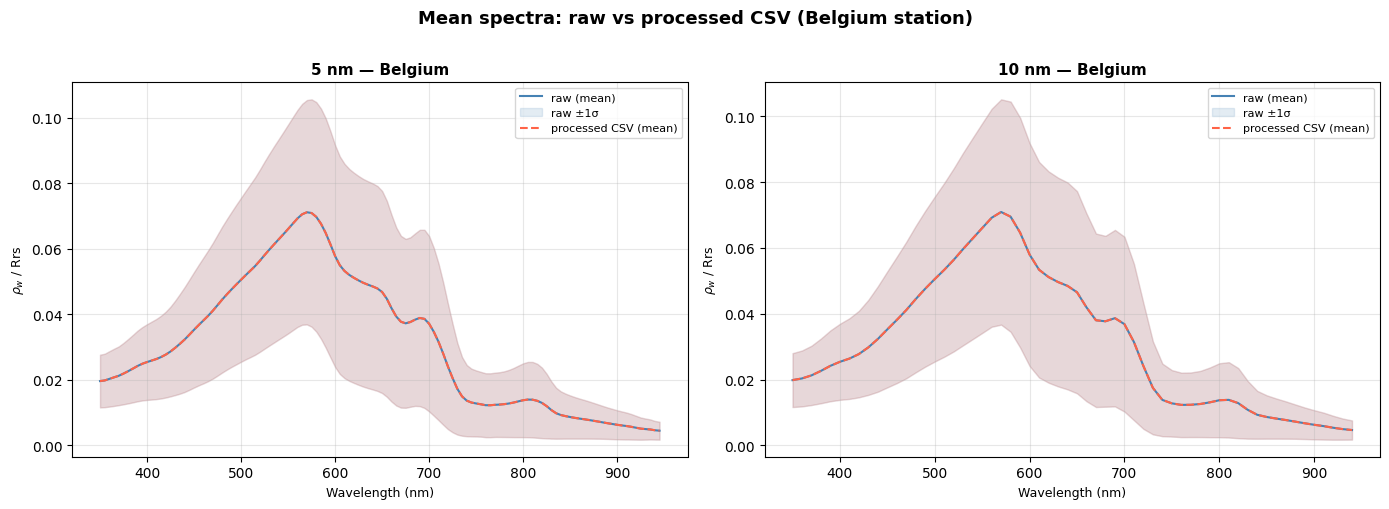

✓ Figure saved as compare_spectra_raw_vs_csv.png


In [10]:
# Belgium-only pairs
pairs = [
    ("chime_05_belgium", "5nm",  "5 nm — Belgium"),
    ("chime_10_belgium", "10nm", "10 nm — Belgium"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (raw_key, csv_key, title) in zip(axes, pairs):
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Raw
    raw_spec = spectra_raw.get(raw_key, {})
    if raw_spec.get("wl") is not None and raw_spec.get("rrs") is not None:
        rrs_r  = raw_spec["rrs"]
        mean_r = np.nanmean(rrs_r, axis=0) if rrs_r.ndim > 1 else rrs_r
        ax.plot(raw_spec["wl"], mean_r, color="steelblue", lw=1.5, label="raw (mean)")
        if rrs_r.ndim > 1:
            std_r = np.nanstd(rrs_r, axis=0)
            ax.fill_between(raw_spec["wl"], mean_r - std_r, mean_r + std_r,
                            alpha=0.15, color="steelblue", label="raw ±1σ")

    # CSV
    csv_spec = spectra_csv.get(csv_key, {})
    if csv_spec.get("wl") is not None and csv_spec.get("rrs") is not None:
        rrs_c  = csv_spec["rrs"]
        mean_c = np.nanmean(rrs_c, axis=0) if rrs_c.ndim > 1 else rrs_c
        ax.plot(csv_spec["wl"], mean_c, color="tomato", lw=1.5, ls="--",
                label="processed CSV (mean)")
        if rrs_c.ndim > 1:
            std_c = np.nanstd(rrs_c, axis=0)
            ax.fill_between(csv_spec["wl"], mean_c - std_c, mean_c + std_c,
                            alpha=0.15, color="tomato")

    ax.set_xlabel("Wavelength (nm)", fontsize=9)
    ax.set_ylabel(r"$\rho_w$ / Rrs", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Mean spectra: raw vs processed CSV (Belgium station)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("compare_spectra_raw_vs_csv.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure saved as compare_spectra_raw_vs_csv.png")

## 9B. Individual spectra — all files (Belgium only)

Rrs / ρw value range per file:
  chime_05_belgium               Rrs range: 0.00016 - 0.18837
  chime_10_belgium               Rrs range: 0.00019 - 0.18766
  5nm                            Rrs range: 0.00016 - 0.18837
  10nm                           Rrs range: 0.00019 - 0.18766


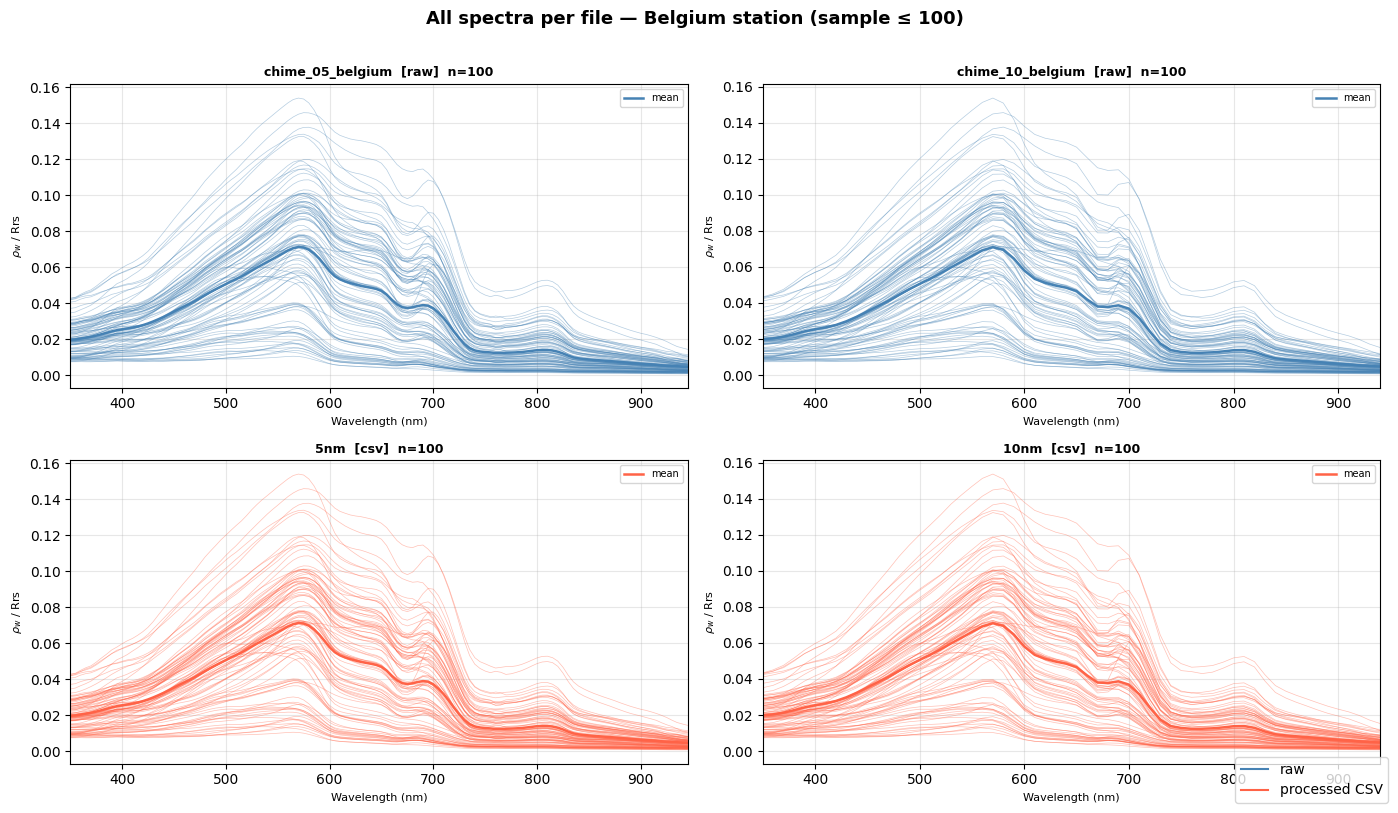


✓ Figure saved as all_spectra_by_file.png


In [11]:
def plot_spectra_file(name, wl, rrs, kind, ax, color):
    """Plot up to 100 spectra from a file on a given axes."""
    if wl is None or rrs is None:
        ax.text(0.5, 0.5, f"{name}\n(no data)", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
        ax.set_title(f"{name} [{kind}]", fontsize=9)
        return

    N = rrs.shape[0] if rrs.ndim > 1 else 1
    plot_idx = np.linspace(0, N - 1, min(N, 100), dtype=int)

    if rrs.ndim == 1:
        ax.plot(wl, rrs, lw=0.8, color=color)
    else:
        for i in plot_idx:
            ax.plot(wl, rrs[i, :], lw=0.5, alpha=0.4, color=color)
        ax.plot(wl, np.nanmean(rrs, axis=0), lw=1.8, color=color,
                alpha=1.0, label="mean")

    ax.set_xlabel("Wavelength (nm)", fontsize=8)
    ax.set_ylabel(r"$\rho_w$ / Rrs", fontsize=8)
    ax.set_title(f"{name}  [{kind}]  n={len(plot_idx)}", fontsize=9, fontweight="bold")
    ax.set_xlim(wl[0], wl[-1])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
    print(f"  {name:<30} Rrs range: {np.nanmin(rrs):.5f} - {np.nanmax(rrs):.5f}")


# Collect Belgium-only files (raw + csv)
all_files = (
    [(k, "raw", spectra_raw[k]["wl"], spectra_raw[k]["rrs"]) for k in spectra_raw] +
    [(k, "csv", spectra_csv[k]["wl"], spectra_csv[k]["rrs"]) for k in spectra_csv]
)

n_files = len(all_files)
ncols   = 2
nrows   = int(np.ceil(n_files / ncols))
palette = {"raw": "steelblue", "csv": "tomato"}

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharey=False)
axes = np.array(axes).flatten()

print("Rrs / ρw value range per file:")
for ax, (name, kind, wl, rrs) in zip(axes, all_files):
    plot_spectra_file(name, wl, rrs, kind, ax, color=palette[kind])

for ax in axes[n_files:]:
    ax.set_visible(False)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", lw=1.5, label="raw"),
    Line2D([0], [0], color="tomato",    lw=1.5, label="processed CSV"),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=10,
           bbox_to_anchor=(1.0, 0.01))

plt.suptitle("All spectra per file — Belgium station (sample ≤ 100)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("all_spectra_by_file.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Figure saved as all_spectra_by_file.png")

---
## 10. Numerical comparison: mean Rrs per band (raw vs CSV)

In [12]:
for res, raw_key, csv_key in [("5nm",  "chime_05_belgium", "5nm"),
                               ("10nm", "chime_10_belgium", "10nm")]:
    raw_spec = spectra_raw.get(raw_key, {})
    csv_spec = spectra_csv.get(csv_key, {})

    if raw_spec.get("wl") is None or csv_spec.get("wl") is None:
        print(f"[{res}] Incomplete data — skipping")
        continue

    # Common wavelength grid
    wl_common = np.intersect1d(
        np.round(raw_spec["wl"], 1),
        np.round(csv_spec["wl"], 1)
    )

    if len(wl_common) == 0:
        print(f"[{res}] No common wavelengths — interpolating")
        wl_common = np.union1d(raw_spec["wl"], csv_spec["wl"])
        mean_raw = np.interp(wl_common, raw_spec["wl"],
                             np.nanmean(raw_spec["rrs"], axis=0)
                             if raw_spec["rrs"].ndim > 1 else raw_spec["rrs"])
        mean_csv = np.interp(wl_common, csv_spec["wl"],
                             np.nanmean(csv_spec["rrs"], axis=0)
                             if csv_spec["rrs"].ndim > 1 else csv_spec["rrs"])
    else:
        raw_mean_all = (np.nanmean(raw_spec["rrs"], axis=0)
                        if raw_spec["rrs"].ndim > 1 else raw_spec["rrs"])
        csv_mean_all = (np.nanmean(csv_spec["rrs"], axis=0)
                        if csv_spec["rrs"].ndim > 1 else csv_spec["rrs"])
        raw_idx = [np.argmin(np.abs(raw_spec["wl"] - w)) for w in wl_common]
        csv_idx = [np.argmin(np.abs(csv_spec["wl"] - w)) for w in wl_common]
        mean_raw = raw_mean_all[raw_idx]
        mean_csv = csv_mean_all[csv_idx]

    diff     = mean_raw - mean_csv
    rel_diff = (diff / (mean_csv + 1e-10)) * 100

    comp_df = pd.DataFrame({
        "λ (nm)"       : wl_common,
        "raw mean"     : np.round(mean_raw, 6),
        "csv mean"     : np.round(mean_csv, 6),
        "abs diff"     : np.round(diff, 6),
        "rel diff (%)" : np.round(rel_diff, 2),
    })

    print(f"\n{'='*55}\n Resolution {res} — common bands: {len(wl_common)}\n{'='*55}")
    display(comp_df.head(20))
    print(f"  RMSE: {np.sqrt(np.mean(diff**2)):.6f}")
    print(f"  MAE : {np.mean(np.abs(diff)):.6f}")
    print(f"  Mean relative difference: {np.mean(np.abs(rel_diff)):.2f}%")


 Resolution 5nm — common bands: 120


,λ (nm),raw mean,csv mean,abs diff,rel diff (%)
0,350.0,0.019610,0.019610,0.0,0.0
1,355.0,0.019798,0.019798,0.0,0.0
2,360.0,0.020279,0.020279,0.0,0.0
3,365.0,0.020759,0.020759,0.0,0.0
4,370.0,0.021229,0.021229,0.0,0.0
5,375.0,0.021893,0.021893,0.0,0.0
6,380.0,0.022631,0.022631,0.0,0.0
7,385.0,0.023415,0.023415,0.0,0.0
8,390.0,0.024227,0.024227,0.0,0.0
9,395.0,0.024892,0.024892,0.0,0.0


  RMSE: 0.000000
  MAE : 0.000000
  Mean relative difference: 0.00%

 Resolution 10nm — common bands: 60


,λ (nm),raw mean,csv mean,abs diff,rel diff (%)
0,350.0,0.019838,0.019838,0.0,0.0
1,360.0,0.020346,0.020346,0.0,0.0
2,370.0,0.021277,0.021277,0.0,0.0
3,380.0,0.022643,0.022643,0.0,0.0
4,390.0,0.024188,0.024188,0.0,0.0
5,400.0,0.025403,0.025403,0.0,0.0
6,410.0,0.026378,0.026378,0.0,0.0
7,420.0,0.027754,0.027754,0.0,0.0
8,430.0,0.029793,0.029793,0.0,0.0
9,440.0,0.032336,0.032336,0.0,0.0


  RMSE: 0.000000
  MAE : 0.000000
  Mean relative difference: 0.00%


---
## 11. Non-spectral (metadata) columns in the CSVs

In [13]:
import re

for key, df in csv_data.items():
    numeric_named = [c for c in df.columns if re.match(r"^\d+\.?\d*$", str(c))]
    prefixed = [c for c in df.columns
                if re.match(r"(Rrs|rrs|wl|band)_?(\d+\.?\d*)", str(c))]
    spectral  = set(numeric_named + prefixed)
    meta_cols = [c for c in df.columns if c not in spectral]

    print(f"\n[{key}] Non-spectral columns ({len(meta_cols)}):")
    for c in meta_cols:
        dtype  = df[c].dtype
        sample = df[c].dropna().iloc[0] if not df[c].dropna().empty else "—"
        print(f"  {c:<30} dtype={str(dtype):<15} example: {sample}")


[5nm] Non-spectral columns (2):
  icase                          dtype=int64           example: 0
  date                           dtype=datetime64[us, UTC] example: 2022-02-26 11:01:30+00:00

[10nm] Non-spectral columns (2):
  icase                          dtype=int64           example: 0
  date                           dtype=datetime64[us, UTC] example: 2022-02-26 11:01:30+00:00
